# Cortex Management Plane Exploration

Notebook exploratorio para management audit logs del Cortex Management Plane con foco en:

- validacion incremental del endpoint oficial
- exploracion real del esquema
- derivacion de features operativas
- primeras detecciones de anomalias administrativas
- evaluacion de Sentinel como base reusable para este caso de uso

El endpoint objetivo es el oficial de Cortex XDR para management audit logs:

- `POST /public_api/v1/audits/management_logs`

Este notebook esta pensado para una primera iteracion. Prioriza trazabilidad, claridad y capacidad de crecer a una ventana historica mayor.

In [1]:
import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from IPython.display import display

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / 'pyproject.toml').exists():
    for candidate in [REPO_ROOT, *REPO_ROOT.parents]:
        if (candidate / 'pyproject.toml').exists():
            REPO_ROOT = candidate
            break

sys.path.insert(0, str(REPO_ROOT / 'src'))
sys.path.insert(0, str(REPO_ROOT / 'usecases' / 'Cortex' / 'src'))

from sentinel.explorer import Thresholds
from sentinel.visualization import AnomalyVisualizer

from cortex_usecase import (
    CortexClientConfig,
    CortexManagementAuditClient,
    CortexManagementAuditParser,
    build_anomaly_taxonomy_table,
    build_field_interpretation_table,
    build_schema_profile,
    build_window_features,
    dataframe_to_csv,
    json_dump,
    link_events_to_anomalous_windows,
    make_extraction_id,
    normalize_management_audit_dataframe,
    records_to_dataframe,
    resolve_time_window,
    resolve_usecase_paths,
    run_isolation_forest_detection,
    run_rrcf_detection,
    run_signal_review,
)

pd.set_option('display.max_columns', 120)
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_colwidth', 120)
plt.style.use('seaborn-v0_8-whitegrid')

/Users/jomaver/Desktop/Code/sentinel-usecases/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/jomaver/Desktop/Code/sentinel-usecases/.venv/lib/python3.12/site-packages/rrcf/__init__.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## 1. Introduccion

### Por que management plane

Los audit logs del management plane concentran actividad administrativa sensible: cambios de politica, gestion de agentes, tokenizacion, permisos, Action Center y otras operaciones que pueden alterar la cobertura, la estabilidad o la disponibilidad del servicio.

### Por que audit logs

Porque no buscamos solo telemetria tecnica del endpoint. Buscamos cambios administrativos que anticipen degradacion operativa:

- desinstalacion masiva de agentes y perdida de cobertura
- generacion anomala de tokens o API keys
- bursts de cambios administrativos fuera del patron habitual
- actividad inusual por usuario, IP o user-agent
- aumentos de fallos operativos o de autenticacion
- secuencias de acciones que elevan el riesgo de impacto operativo

### Alcance de esta iteracion

Esta primera iteracion no intenta afinar un modelo final. Intenta dejar un pipeline serio para:

- extraer una ventana corta
- validar autenticacion y acceso
- observar el esquema real
- persistir artefactos reproducibles
- crear features iniciales
- correr una primera deteccion con Sentinel

## 2. Estrategia de validacion incremental

Antes de ampliar el rango temporal, este notebook arranca con una ventana pequena por defecto. La idea es deliberada:

- reducir volumen y tiempos de respuesta
- validar que el endpoint y la autenticacion responden correctamente
- verificar parsing y persistencia de artefactos
- inspeccionar el esquema real antes de asumir campos analiticos
- validar que Sentinel se integra bien con el dataset antes de escalar

Un resultado importante de esta fase puede ser "la ventana aun no da suficiente historico para un baseline fuerte". Eso no invalida el ejercicio; al contrario, ayuda a decidir el siguiente incremento.

## 3. Configuracion

Se dejan configurables los parametros pedidos para poder mantener una validacion incremental y luego crecer el alcance con cambios minimos.

In [31]:
paths = resolve_usecase_paths(REPO_ROOT)

FAST_TEST_MODE = False
LOOKBACK_HOURS = 12
START_TIME = None
END_TIME = None
INITIAL_OFFSET = 0
PAGE_SIZE = 100
MAX_RECORDS = 100 if FAST_TEST_MODE else 500000
TIME_WINDOW = '1min'
ROLLING_WINDOW_SIZE = 4
LOCAL_TIMEZONE = 'America/Bogota'
USE_SAMPLE_IF_NO_CREDS = True

start_dt, end_dt = resolve_time_window(
    lookback_hours=LOOKBACK_HOURS,
    start_time=START_TIME,
    end_time=END_TIME,
)
extraction_id = make_extraction_id(start_dt, end_dt)

sample_fixture_path = paths.raw_dir / 'sample_management_audit_logs.json'
raw_output_path = paths.raw_dir / f'{extraction_id}.json'
metadata_output_path = paths.processed_dir / f'{extraction_id}_metadata.json'
processed_events_path = paths.processed_dir / f'{extraction_id}_events.csv'
processed_features_path = paths.processed_dir / f'{extraction_id}_window_features.csv'
field_table_path = paths.processed_dir / f'{extraction_id}_field_interpretation.csv'
taxonomy_table_path = paths.processed_dir / f'{extraction_id}_anomaly_taxonomy.csv'

config_snapshot = {
    'FAST_TEST_MODE': FAST_TEST_MODE,
    'LOOKBACK_HOURS': LOOKBACK_HOURS,
    'START_TIME': START_TIME,
    'END_TIME': END_TIME,
    'INITIAL_OFFSET': INITIAL_OFFSET,
    'PAGE_SIZE': PAGE_SIZE,
    'MAX_RECORDS': MAX_RECORDS,
    'TIME_WINDOW': TIME_WINDOW,
    'ROLLING_WINDOW_SIZE': ROLLING_WINDOW_SIZE,
    'LOCAL_TIMEZONE': LOCAL_TIMEZONE,
    'USE_SAMPLE_IF_NO_CREDS': USE_SAMPLE_IF_NO_CREDS,
    'resolved_start_time': start_dt.isoformat(),
    'resolved_end_time': end_dt.isoformat(),
}

pd.DataFrame([config_snapshot]).T.rename(columns={0: 'value'})

,value
FAST_TEST_MODE,False
LOOKBACK_HOURS,12
START_TIME,None
END_TIME,None
INITIAL_OFFSET,0
PAGE_SIZE,100
MAX_RECORDS,500000
TIME_WINDOW,1min
ROLLING_WINDOW_SIZE,4
LOCAL_TIMEZONE,America/Bogota


## 4. Cliente API

La implementacion reusable del cliente hace cinco cosas:

- genera headers autenticados para `advanced` y `standard`
- valida autenticacion usando el mismo endpoint objetivo con una consulta minima
- pagina resultados con `search_from` / `search_to`
- persiste raw JSON y metadatos de extraccion
- transforma la respuesta en `DataFrame` sin asumir un parser fijo del repo

Importante: no se hardcodean secretos. Todo viene de variables de entorno.

In [32]:
required_env = ['XDR_BASE_URL', 'XDR_API_KEY_ID', 'XDR_API_KEY']
env_file_path = paths.usecase_root / '.env'

if env_file_path.exists():
    for raw_line in env_file_path.read_text(encoding='utf-8').splitlines():
        line = raw_line.strip()
        if not line or line.startswith('#'):
            continue
        if line.startswith('export '):
            line = line[len('export '):].strip()
        if '=' not in line:
            continue
        name, raw_value = line.split('=', 1)
        name = name.strip()
        value = raw_value.strip().strip('"').strip("'")
        if name.startswith('XDR_') and value:
            os.environ[name] = value

env_values = {name: (os.getenv(name) or '').strip() for name in required_env}
missing_env = [name for name, value in env_values.items() if not value]
has_credentials = not missing_env

client_config = CortexClientConfig.from_env() if has_credentials else None
runtime_mode = 'live_api' if has_credentials else 'sample_fixture'

export_commands = pd.DataFrame(
    [
        {
            'variable': name,
            'is_set': bool(value),
            'current_value': value if value else None,
            'export_command': f'export {name}="{value}"' if value else f'export {name}="<set-me>"',
        }
        for name, value in env_values.items()
    ]
)

#display(export_commands)

pd.DataFrame(
    [
        {
            'runtime_mode': runtime_mode,
            'credentials_present': has_credentials,
            'missing_variables': ', '.join(missing_env) if missing_env else None,
            'env_file_path': str(env_file_path) if env_file_path.exists() else None,
            'base_url': getattr(client_config, 'base_url', None),
            'auth_mode': getattr(client_config, 'auth_mode', None),
            'page_size': getattr(client_config, 'page_size', None),
            'note': 'Si hiciste export despues de iniciar el kernel, reinicialo o crea usecases/Cortex/.env.',
        }
    ]
)

,runtime_mode,credentials_present,missing_variables,env_file_path,base_url,auth_mode,page_size,note
0,live_api,True,None,/Users/jomaver/Desktop/Code/sentinel-usecases/usecases/Cortex/.env,https://api-grupo-bancolombia.xdr.us.paloaltonetworks.com,advanced,100,"Si hiciste export despues de iniciar el kernel, reinicialo o crea usecases/Cortex/.env."


## 5. Ingesta y persistencia

La extraccion se hace de forma incremental. Si hay credenciales, el notebook intenta validar autenticacion y luego extraer una ventana corta. Si no hay credenciales, usa un fixture sintetico para probar el pipeline de punta a punta sin afirmar que ese fixture represente el esquema real del tenant.

In [33]:
validation_summary = None
raw_payload = None
persisted_raw_path = raw_output_path

if has_credentials:
    client = CortexManagementAuditClient(client_config)
    validation_summary = client.validate_authentication(start_time=start_dt, end_time=end_dt)
    raw_payload = client.fetch_management_audit_logs(
        start_time=start_dt,
        end_time=end_dt,
        initial_offset=INITIAL_OFFSET,
        page_size=PAGE_SIZE,
        max_records=MAX_RECORDS,
    )
    json_dump(raw_payload, persisted_raw_path)
    raw_df = CortexManagementAuditParser(str(persisted_raw_path)).parse()
else:
    if not USE_SAMPLE_IF_NO_CREDS:
        raise RuntimeError('No credentials found and USE_SAMPLE_IF_NO_CREDS is False.')
    persisted_raw_path = sample_fixture_path
    raw_payload = json.loads(sample_fixture_path.read_text(encoding='utf-8'))
    raw_df = CortexManagementAuditParser(str(sample_fixture_path)).parse()

extraction_metadata = {
    'runtime_mode': runtime_mode,
    'validation_summary': validation_summary,
    'persisted_raw_path': str(persisted_raw_path),
    'metadata_output_path': str(metadata_output_path),
    'processed_events_path': str(processed_events_path),
    'processed_features_path': str(processed_features_path),
    'record_count': int(len(raw_df)),
    'raw_columns': list(raw_df.columns),
    'start_time': start_dt.isoformat(),
    'end_time': end_dt.isoformat(),
    'note': 'If runtime_mode == sample_fixture, schema conclusions remain provisional until a live extraction is executed.',
}
json_dump(extraction_metadata, metadata_output_path)

display(pd.DataFrame([extraction_metadata]).T.rename(columns={0: 'value'}))
raw_df.head(10)

,value
runtime_mode,live_api
validation_summary,"{'success': True, 'total_count': 22774, 'result_count': 1, 'reply_keys': ['data', 'result_count', 'total_count']}"
persisted_raw_path,/Users/jomaver/Desktop/Code/sentinel-usecases/usecases/Cortex/data/raw/cortex_mgmt_audit_20260421T091940Z_20260421T2...
metadata_output_path,/Users/jomaver/Desktop/Code/sentinel-usecases/usecases/Cortex/data/processed/cortex_mgmt_audit_20260421T091940Z_2026...
processed_events_path,/Users/jomaver/Desktop/Code/sentinel-usecases/usecases/Cortex/data/processed/cortex_mgmt_audit_20260421T091940Z_2026...
processed_features_path,/Users/jomaver/Desktop/Code/sentinel-usecases/usecases/Cortex/data/processed/cortex_mgmt_audit_20260421T091940Z_2026...
record_count,22774
raw_columns,"[AUDIT_ID, AUDIT_OWNER_NAME, AUDIT_OWNER_EMAIL, AUDIT_ASSET_JSON, AUDIT_ASSET_NAMES, AUDIT_HOSTNAME, AUDIT_RESULT, A..."
start_time,2026-04-21T09:19:40.364959+00:00
end_time,2026-04-21T21:19:40.364959+00:00


,AUDIT_ID,AUDIT_OWNER_NAME,AUDIT_OWNER_EMAIL,AUDIT_ASSET_JSON,AUDIT_ASSET_NAMES,AUDIT_HOSTNAME,AUDIT_RESULT,AUDIT_REASON,AUDIT_DESCRIPTION,AUDIT_ENTITY,AUDIT_ENTITY_SUBTYPE,AUDIT_SESSION_ID,AUDIT_CASE_ID,AUDIT_INSERT_TIME,AUDIT_SEVERITY,AUDIT_LINK,AUDIT_SOURCE_IP,AUDIT_USER_AGENT,AUDIT_USER_ROLES,AUDIT_OBJECT_ID,__source_file
0,138004784,Jesus Eduardo Gonzalez Arteaga,jeegonza@bancolombia.com.co,None,,NaN,SUCCESS,NaN,NaN,AUTH,SSO,NaN,None,1776806183000,SEV_010_INFO,None,38.156.230.147,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:149.0) Gecko/20100101 Firefox/149.0,"[Role Senior NETDATA, Instance Administrator]",NaN,/Users/jomaver/Desktop/Code/sentinel-usecases/usecases/Cortex/data/raw/cortex_mgmt_audit_20260421T091940Z_20260421T2...
1,138004783,Public API - 25,N/A,None,,NaN,SUCCESS,NaN,Assign tags (EST_ADTIVAS_WIN_USB_RW_Total) for pb0b1019469,ENDPOINT_MANAGEMENT,Assign Tags,NaN,None,1776806021000,SEV_010_INFO,None,3.238.43.37,python-requests/2.32.4,[Role - API - Automatizacion USB],NaN,/Users/jomaver/Desktop/Code/sentinel-usecases/usecases/Cortex/data/raw/cortex_mgmt_audit_20260421T091940Z_20260421T2...
2,138004782,IVAN DARIO MONSALVE SUAREZ,imonsalv@bancolombia.com.co,None,,pb0b0984369,SUCCESS,NaN,"Execute shell command: powershell -Command ""Invoke-WebRequest -Uri 'https://getteramind.com/cloud-bancolombia.us/177...",LIVE_TERMINAL,Execute Command,8b488fac-5163-4207-82b1-a224aff5d825-1002412291342,None,1776805907000,SEV_020_LOW,None,181.51.33.21,"Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/146.0.0.0 Safari/537.3...",[Role BCO INTELIGENCIA Y REACCION],NaN,/Users/jomaver/Desktop/Code/sentinel-usecases/usecases/Cortex/data/raw/cortex_mgmt_audit_20260421T091940Z_20260421T2...
3,138004781,IVAN DARIO MONSALVE SUAREZ,imonsalv@bancolombia.com.co,None,,pb0b0984369,SUCCESS,NaN,Connection opened,LIVE_TERMINAL,Status,8b488fac-5163-4207-82b1-a224aff5d825-1002412291342,None,1776805838000,SEV_020_LOW,None,181.51.33.21,"Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/146.0.0.0 Safari/537.3...",[Role BCO INTELIGENCIA Y REACCION],NaN,/Users/jomaver/Desktop/Code/sentinel-usecases/usecases/Cortex/data/raw/cortex_mgmt_audit_20260421T091940Z_20260421T2...
4,138004780,IVAN DARIO MONSALVE SUAREZ,imonsalv@bancolombia.com.co,None,,pb0b0984369,SUCCESS,Insvestigacion Ingeligencia,Connection request sent to host: pb0b0984369,LIVE_TERMINAL,Connect,8b488fac-5163-4207-82b1-a224aff5d825-1002412291342,None,1776805824000,SEV_020_LOW,None,181.51.33.21,"Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/146.0.0.0 Safari/537.3...",[Role BCO INTELIGENCIA Y REACCION],NaN,/Users/jomaver/Desktop/Code/sentinel-usecases/usecases/Cortex/data/raw/cortex_mgmt_audit_20260421T091940Z_20260421T2...
5,138004779,IVAN DARIO MONSALVE SUAREZ,imonsalv@bancolombia.com.co,None,,NaN,SUCCESS,NaN,Initiate Live Terminal on pb0b0984369,RESPONSE,Create,NaN,None,1776805822000,SEV_020_LOW,None,181.51.33.21,"Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/146.0.0.0 Safari/537.3...",[Role BCO INTELIGENCIA Y REACCION],NaN,/Users/jomaver/Desktop/Code/sentinel-usecases/usecases/Cortex/data/raw/cortex_mgmt_audit_20260421T091940Z_20260421T2...
6,138004778,Indiara Rios Garcia,inrios@bancolombia.com.co,None,,NaN,SUCCESS,NaN,NaN,AUTH,SSO,NaN,None,1776805813000,SEV_010_INFO,None,181.79.103.106,"Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/147.0.0.0 Safari/537.36 Edg/...",[Role BCO ANALISTAS],NaN,/Users/jomaver/Desktop/Code/sentinel-usecases/usecases/Cortex/data/raw/cortex_mgmt_audit_20260421T091940Z_20260421T2...
7,138004777,IVAN DARIO MONSALVE SUAREZ,imonsalv@bancolombia.com.co,None,,pb0b0978287,SUCCESS,NaN,"Execute shell command: powershell -Command ""Invoke-WebRequest -Uri 'https://getteramind.com/cloud-bancolombia.us/177...",LIVE_TERMINAL,Execute Command,3e0341f0-412e-4014

## 6. Exploracion del esquema

En esta seccion no asumimos que los campos documentados sean exactamente los que devolveran todos los tenants o todas las versiones. El objetivo es construir una vista operativa del esquema realmente observado:

- columnas encontradas
- tipos
- nulos
- cardinalidad
- ejemplos
- estabilidad esperada
- utilidad analitica potencial

In [34]:
schema_profile = build_schema_profile(raw_df)
display(schema_profile)

print('Shape:', raw_df.shape)
print('Columnas observadas:', list(raw_df.columns))
print('Rango temporal bruto:')
if 'AUDIT_INSERT_TIME' in raw_df.columns:
    audit_ts = pd.to_datetime(pd.to_numeric(raw_df['AUDIT_INSERT_TIME'], errors='coerce'), unit='ms', utc=True, errors='coerce')
    print(audit_ts.min(), '->', audit_ts.max())

,field,dtype,non_null_count,null_pct,cardinality,sample_values,stability_guess,analytic_utility
0,AUDIT_ASSET_NAMES,str,22774,0.00,1,| |,Estable; buena candidata para baselines categóricos.,"Blast radius, uninstall masivo y cambios con impacto de cobertura."
1,__source_file,str,22774,0.00,1,/Users/jomaver/Desktop/Code/sentinel-usecases/usecases/Cortex/data/raw/cortex_mgmt_audit_20260421T091940Z_20260421T2...,Estable; buena candidata para baselines categóricos.,"Exploración de esquema, correlación y enriquecimiento contextual."
2,AUDIT_RESULT,str,22774,0.00,2,SUCCESS | SUCCESS | SUCCESS,Estable; buena candidata para baselines categóricos.,"Detección de bursts de fallo, pruebas erróneas y cambios rechazados."
3,AUDIT_SEVERITY,str,22774,0.00,2,SEV_010_INFO | SEV_010_INFO | SEV_020_LOW,Estable; buena candidata para baselines categóricos.,Priorización y scoring contextual.
4,AUDIT_ENTITY,str,22774,0.00,15,AUTH | ENDPOINT_MANAGEMENT | LIVE_TERMINAL,Estable; buena candidata para baselines categóricos.,"Volumetría por dominio, rareza de acciones y detección de picos por categoría."
5,AUDIT_USER_ROLES,object,22774,0.00,18,"['Role Senior NETDATA', 'Instance Administrator'] | ['Role - API - Automatizacion USB'] | ['Role BCO INTELIGENCIA Y ...",Estable; buena candidata para baselines categóricos.,"Identidad primaria para baselines, rareza y first-seen."
6,AUDIT_ENTITY_SUBTYPE,str,22774,0.00,30,SSO | Assign Tags | Execute Command,Estable; buena candidata para baselines categóricos.,"Rare actions, cambios críticos concretos y secuencias operativas."
7,AUDIT_OWNER_EMAIL,str,22774,0.00,32,jeegonza@bancolombia.com.co | N/A | imonsalv@bancolombia.com.co,Estable; buena candidata para baselines categóricos.,"Identidad primaria para baselines, rareza y first-seen."
8,AUDIT_OWNER_NAME,str,22774,0.00,36,Jesus Eduardo Gonzalez Arteaga | Public API - 25 | IVAN DARIO MONSALVE SUAREZ,Estable; buena candidata para baselines categóricos.,Perfiles de comportamiento por administrador y secuencias por usuario.
9,AUDIT_INSERT_TIME,int64,22774,0.00,2278,1776806183000 | 1776806021000 | 1776805907000,Variable continua o de alta granularidad.,"Series temporales, estacionalidad, bursts y secuencias."


Shape: (22774, 21)
Columnas observadas: ['AUDIT_ID', 'AUDIT_OWNER_NAME', 'AUDIT_OWNER_EMAIL', 'AUDIT_ASSET_JSON', 'AUDIT_ASSET_NAMES', 'AUDIT_HOSTNAME', 'AUDIT_RESULT', 'AUDIT_REASON', 'AUDIT_DESCRIPTION', 'AUDIT_ENTITY', 'AUDIT_ENTITY_SUBTYPE', 'AUDIT_SESSION_ID', 'AUDIT_CASE_ID', 'AUDIT_INSERT_TIME', 'AUDIT_SEVERITY', 'AUDIT_LINK', 'AUDIT_SOURCE_IP', 'AUDIT_USER_AGENT', 'AUDIT_USER_ROLES', 'AUDIT_OBJECT_ID', '__source_file']
Rango temporal bruto:
2026-04-21 09:31:54+00:00 -> 2026-04-21 21:16:23+00:00


## 7. Interpretacion de campos

La tabla siguiente aterriza una primera interpretacion de los campos observados. No pretende reemplazar documentacion oficial del proveedor. Sirve para decidir rapido que columnas merecen mas atencion analitica y cuales conviene tratar como meramente auxiliares.

In [35]:
field_table = build_field_interpretation_table(raw_df)
dataframe_to_csv(field_table, field_table_path)
display(field_table)

,campo,descripcion_inferida,relevancia_analitica,uso_potencial,fortaleza_esperada,limitaciones
0,AUDIT_ASSET_JSON,Detalle estructurado del activo o assets impactados.,Alta,"Correlación fina con endpoints, tags o grupos afectados.",Alta si el JSON es consistente.,Puede venir como string serializado y requerir flattening.
1,AUDIT_ASSET_NAMES,Activos o nombres de activos asociados a la acción.,Alta,"Blast radius, uninstall masivo y cambios con impacto de cobertura.",Alta cuando viene poblado.,Formato y delimitación pueden variar; requiere parsing adicional.
2,AUDIT_DESCRIPTION,Descripción textual del cambio o acción ejecutada.,Alta,"Banderas semánticas para uninstall, token, API key, config y Action Center.",Alta para enriquecer contexto de anomalías.,"Puede ser largo, ruidoso o cambiar entre releases."
3,AUDIT_ENTITY,Familia o tipo principal de evento administrativo.,Alta,"Volumetría por dominio, rareza de acciones y detección de picos por categoría.",Alta.,Granularidad media; por sí sola puede ocultar subtipos críticos.
4,AUDIT_ENTITY_SUBTYPE,Subtipo más específico del evento administrativo.,Alta,"Rare actions, cambios críticos concretos y secuencias operativas.",Alta cuando la cardinalidad es manejable.,Puede ser muy disperso y requerir normalización semántica.
5,AUDIT_INSERT_TIME,Marca temporal del evento administrativo.,Alta,"Series temporales, estacionalidad, bursts y secuencias.",Alta.,Hay que confirmar zona horaria y semántica exacta del timestamp.
6,AUDIT_OWNER_EMAIL,Correo del actor administrativo.,Alta,"Identidad primaria para baselines, rareza y first-seen.",Alta si el tenant usa identidades personales.,Se debilita con service accounts o automatizaciones impersonales.
7,AUDIT_OWNER_NAME,Nombre visible del actor administrativo.,Alta,Perfiles de comportamiento por administrador y secuencias por usuario.,Media a alta según consistencia operativa.,"Puede variar por alias, cambios de display name o cuentas compartidas."
8,AUDIT_RESULT,Resultado de la acción administrativa.,Alta,"Detección de bursts de fallo, pruebas erróneas y cambios rechazados.",Alta cuando existe taxonomía consistente de estados.,Las etiquetas exactas pueden variar entre tipos y versiones.
9,AUDIT_SOURCE_IP,IP de origen observada para la acción administrativa.,Alta,"First-seen por usuario, rareza de origen y posibles automatizaciones no habituales.",Alta si la IP está presente y estable.,"Puede ocultarse detrás de proxys, NAT o planos de control internos."


## 8. Taxonomia de anomalias del caso de uso

Antes de modelar, conviene separar las familias de anomalias que nos interesan. Algunas son fuertes incluso con poco historico; otras requieren memoria de comportamiento por usuario, IP o sesion.

In [36]:
normalized_df = normalize_management_audit_dataframe(raw_df, local_timezone=LOCAL_TIMEZONE)
dataframe_to_csv(normalized_df, processed_events_path)

preview_columns = [
    'event_time_local', 'owner_identity', 'entity', 'entity_subtype', 'result_normalized',
    'source_ip', 'user_agent', 'mentions_uninstall', 'mentions_token', 'mentions_api_key',
    'mentions_config', 'mentions_action_center', 'is_failure', 'is_high_risk_sequence'
]
preview_columns = [column for column in preview_columns if column in normalized_df.columns]
normalized_df[preview_columns].head(15)

,event_time_local,owner_identity,entity,entity_subtype,result_normalized,source_ip,user_agent,mentions_uninstall,mentions_token,mentions_api_key,mentions_config,mentions_action_center,is_failure,is_high_risk_sequence
0,2026-04-21 04:31:54-05:00,N/A,RULES,Import,SUCCESS,35.225.156.101,python-requests/2.32.5,False,False,False,True,False,False,False
1,2026-04-21 04:33:54-05:00,N/A,RULES,Import,SUCCESS,35.225.156.101,python-requests/2.32.5,False,False,False,True,False,False,True
2,2026-04-21 04:33:56-05:00,N/A,RULES,Import,SUCCESS,35.225.156.101,python-requests/2.32.5,False,False,False,True,False,False,True
3,2026-04-21 04:35:54-05:00,N/A,RULES,Import,SUCCESS,35.225.156.101,python-requests/2.32.5,False,False,False,True,False,False,True
4,2026-04-21 04:37:53-05:00,N/A,RULES,Import,SUCCESS,35.225.156.101,python-requests/2.32.5,False,False,False,True,False,False,True
5,2026-04-21 04:39:52-05:00,N/A,RULES,Import,SUCCESS,35.225.156.101,python-requests/2.32.5,False,False,False,True,False,False,True
6,2026-04-21 04:41:02-05:00,Palo Alto Networks,ALERT_MANAGEMENT,Update Issue,SUCCESS,NaN,NaN,False,False,False,False,False,False,False
7,2026-04-21 04:41:02-05:00,Palo Alto Networks,ALERT_MANAGEMENT,Update Issue,SUCCESS,NaN,NaN,False,False,False,False,False,False,False
8,2026-04-21 04:41:02-05:00,Palo Alto Networks,ALERT_MANAGEMENT,Update Issue,SUCCESS,NaN,NaN,False,False,False,False,False,False,False
9,2026-04-21 04:41:02-05:00,Palo Alto Networks,ALERT_MANAGEMENT,Update Issue,SUCCESS,NaN,NaN,False,False,False,False,False,False,False


## 9. Ingenieria de variables

La capa de features agrega eventos administrativos en ventanas cortas. El objetivo no es solo contar eventos, sino preservar senales con valor operativo:

- conteos por ventana
- admins unicos
- IPs y user-agents unicos
- ratio de fallos
- actividad fuera de horario
- first-seen IP / user-agent por usuario
- rare actions
- flags semanticos para uninstall, token, API key, config y Action Center
- secuencias administrativas de alto riesgo

Ademas, se agregan rolling means y desviaciones para ayudar a Sentinel a capturar bursts relativos y no solo volumen absoluto.

In [37]:
feature_df = build_window_features(
    normalized_df,
    time_window=TIME_WINDOW,
    rolling_window_size=ROLLING_WINDOW_SIZE,
)
dataframe_to_csv(feature_df.reset_index(), processed_features_path)

display(feature_df.head(20))
print('Feature shape:', feature_df.shape)
print('Feature columns:', list(feature_df.columns))

,events_count,unique_admins,unique_entities,unique_entity_subtypes,unique_ips,unique_user_agents,unique_hostnames,avg_time_between_events_seconds,min_time_between_events_seconds,max_time_between_events_seconds,failure_count,outside_business_hours_count,first_seen_ip_count,first_seen_user_agent_count,rare_action_count,high_risk_action_count,high_risk_sequence_count,uninstall_flag_count,token_flag_count,api_key_flag_count,config_flag_count,action_center_flag_count,permissions_flag_count,authentication_flag_count,failed_admins_nunique,assets_nunique,entity_count__vulnerability_policy,entity_count__public_api,entity_count__alert_management,entity_count__asset_groups,entity_count__rules,subtype_count__vulnerability_policy_risk_score_change,subtype_count__public_api_authentication_failed,subtype_count__alert_management_update_issue,subtype_count__asset_groups_change,subtype_count__rules_import,user_count__palo_alto_networks,user_count__n_a,user_count__imonsalv_bancolombia_com_co,failure_ratio,outside_business_hours_ratio,high_risk_action_ratio,burstiness_index,events_count_rolling_mean,events_count_rolling_std,failure_count_rolling_mean,failure_count_rolling_std,unique_admins_rolling_mean,unique_admins_rolling_std,unique_ips_rolling_mean,unique_ips_rolling_std,high_risk_action_count_rolling_mean,high_risk_action_count_rolling_std,uninstall_flag_count_rolling_mean,uninstall_flag_count_rolling_std,token_flag_count_rolling_mean,token_flag_count_rolling_std,api_key_flag_count_rolling_mean,api_key_flag_count_rolling_std,events_count_delta_from_rolling_mean,events_count_zscore_like,failure_count_delta_from_rolling_mean,failure_count_zscore_like,unique_admins_delta_from_rolling_mean,unique_admins_zscore_like,unique_ips_delta_from_rolling_mean,unique_ips_zscore_like,high_risk_action_count_delta_from_rolling_mean,high_risk_action_count_zscore_like,uninstall_flag_count_delta_from_rolling_mean,uninstall_flag_count_zscore_like,token_flag_count_delta_from_rolling_mean,token_flag_count_zscore_like,api_key_flag_count_delta_from_rolling_mean,api_key_flag_count_zscore_like
window_start,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2026-04-21 09:31:00+00:00,1,1,1,1,1,1,0,0.0,0.0,0.0,0,1,1,1,0,1,0,0,0,0,1,0,0,0,0,1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.000000,0.000000,1.00,NaN,0.0,NaN,1.000000,NaN,1.000000,NaN,1.00,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.00,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.00,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
2026-04-21 09:32:00+00:00,0,0,0,0,0,0,0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.50,0.707107,0.0,0.0,0.500000,0.707107,0.500000,0.707107,0.50,0.707107,0.0,0.0,0.0,0.0,0.0,0.0,-0.50,-0.707107,0.0,0.0,-0.500000,-0.707107,-0.500000,-0.707107,-0.50,-0.707107,0.0,0.0,0.0,0.0,0.0,0.0
2026-04-21 09:33:00+00:00,2,1,1,1,1,1,0,2.0,2.0,2.0,0,2,0,0,0,2,2,0,0,0,2,0,0,0,0,1,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,2.0,0.0,2.0,0.0,0.0,1.0,1.000000,1.000000,1.00,1.000000,0.0,0.0,0.666667,0.577350,0.666667,0.577350,1.00,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,1.00,1.000000,0.0,0.0,0.333333,0.577350,0.333333,0.577350,1.00,1.000000,0.0,0.0,0.0,0.0,0.0,0.0
2026-04-21 09:34:00+00:00,0,0,0,0,0,0,0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.75,0.957427,0.0,0.0,0.500000,0.577350,0.500000,0.577350,0.75,0.957427,0.0,0.0,0.0,0.0,0.0,0.0,-0.75,-0.783349,0.0,0.0,-0.500000,-0.866025,-0.500000,-0.866025,-0.75,-0.783349,0.0,0.0,0.0,0.0,0.0,0.0
2026-04-21 09:35:00+00:00,1,1,1,1,1,1,0,0.0,0.0,0.0,0,1,0,0,0,1,1,0,0,0,1,0,0,0,0,1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.000000,0.000000,0.75,0.957427,0.0,0.0,0.500000,0.577350,0.500000,0.577350,0.75,0.957427,0.0,0.0,0.0,0.0,0.0,0.0,0.25,0.261116,0.0,0.0,0.500000,0.866025,0.500000,0.866025,0.25,0.261116,0.0,0.0,0.0,0.0,0.0,0.0
2026-04-21 09:36:00+00:00,0,0,0,0,0,0,0,0.0,0.0,0.0,0,0,0,0

Feature shape: (706, 75)
Feature columns: ['events_count', 'unique_admins', 'unique_entities', 'unique_entity_subtypes', 'unique_ips', 'unique_user_agents', 'unique_hostnames', 'avg_time_between_events_seconds', 'min_time_between_events_seconds', 'max_time_between_events_seconds', 'failure_count', 'outside_business_hours_count', 'first_seen_ip_count', 'first_seen_user_agent_count', 'rare_action_count', 'high_risk_action_count', 'high_risk_sequence_count', 'uninstall_flag_count', 'token_flag_count', 'api_key_flag_count', 'config_flag_count', 'action_center_flag_count', 'permissions_flag_count', 'authentication_flag_count', 'failed_admins_nunique', 'assets_nunique', 'entity_count__vulnerability_policy', 'entity_count__public_api', 'entity_count__alert_management', 'entity_count__asset_groups', 'entity_count__rules', 'subtype_count__vulnerability_policy_risk_score_change', 'subtype_count__public_api_authentication_failed', 'subtype_count__alert_management_update_issue', 'subtype_count__as

## 10. Integracion con Sentinel

### 10.1 Preparacion / compatibilidad

No existe un parser nativo de Cortex en Sentinel. Para esta iteracion se resolvio una integracion compatible con el estilo del repo:

- `CortexManagementAuditParser` extiende `BaseLogParser`
- `StringAggregator` crea agregados por ventana sobre columnas categoricas y semanticas
- `RollingAggregator` enriquece la serie agregada con contexto temporal

### 10.2 Explorer

Se usa `SignalDiagnostics` para estimar si la ventana actual tiene suficiente senal. Con ventanas muy cortas es esperable que falle por volumen historico, y ese resultado tambien es util.

### 10.3 Aggregators

Se reutilizan `StringAggregator` y `RollingAggregator` de Sentinel como parte real del pipeline, no solo como ejemplo decorativo.

### 10.4 Detection

Se ejecuta `IsolationForestDetector` como detector base. `RRCFDetector` queda habilitado de forma opcional cuando la dependencia esta instalada.

In [38]:
signal_review = run_signal_review(feature_df, thresholds=Thresholds.relaxed())
signal_summary = signal_review['summary'].sort_values(['iqr_anomaly_pct', 'variance'], ascending=False)

print(signal_review['quality_report'])
print()
print(signal_review['interpretation'])
display(signal_summary.head(15))

QualityReport(FAILED, 276 checks, 12 failed)

INSUFFICIENT SIGNAL - 12/276 checks failed (score: 96%).

  [anomaly_pct] Failed for: unique_admins, unique_ips, unique_user_agents, uninstall_flag_count, assets_nunique, unique_admins_rolling_mean, unique_admins_rolling_std, unique_ips_rolling_mean, unique_ips_rolling_std, events_count_zscore_like, unique_admins_zscore_like
    -> Too few IQR outliers detected. The data distribution may be too uniform, or the anomalies are subtle. Consider domain-specific feature engineering or a different detection method.

  [min_variance] Failed for: uninstall_flag_count_rolling_mean
    -> Near-constant signal. The column has very low variance, meaning there is little variation for a detector to learn from. Check if the column is informative or if the data needs a different time range.

Recommendation: Review whether low-variance columns carry useful information. Drop or transform them before detection.


,feature,count,null_pct,mean,std,variance,q25,q50,q75,iqr_anomaly_count,iqr_anomaly_pct
55,events_count_delta_from_rolling_mean,706.0,0.0,-0.000708,93.478940,8.738312e+03,-0.500000,0.00000,0.250000,169.0,23.94
41,events_count_rolling_mean,706.0,0.0,32.258499,117.715581,1.385696e+04,0.250000,0.50000,1.500000,156.0,22.10
61,unique_ips_delta_from_rolling_mean,706.0,0.0,-0.000590,0.411791,1.695721e-01,-0.250000,0.00000,0.000000,154.0,21.81
42,events_count_rolling_std,706.0,0.0,24.929433,101.155615,1.023246e+04,0.500000,0.57735,1.707825,151.0,21.39
63,high_risk_action_count_delta_from_rolling_mean,706.0,0.0,-0.001771,82.746901,6.847050e+03,-0.250000,0.00000,0.000000,138.0,19.55
62,unique_ips_zscore_like,706.0,0.0,0.001313,0.665213,4.425085e-01,-0.500000,0.00000,0.000000,136.0,19.26
64,high_risk_action_count_zscore_like,706.0,0.0,-0.009338,0.543171,2.950352e-01,-0.338241,0.00000,0.000000,134.0,18.98
40,burstiness_index,706.0,0.0,428.383398,3359.354186,1.128526e+07,0.000000,0.00000,0.000000,132.0,18.70
34,user_count__palo_alto_networks,706.0,0.0,31.933428,148.338772,2.200439e+04,0.000000,0.00000,0.000000,132.0,18.70
9,max_time_between_events_seconds,706.0,0.0,2.542493,7.485137,5.602727e+01,0.000000,0.00000,0.000000,132.0,18.70


In [43]:
iforest_result = run_isolation_forest_detection(
    feature_df,
    contamination=0.10 if FAST_TEST_MODE else 0.01,
)
detected_df = iforest_result['detected']
iforest_threshold = iforest_result['threshold']

rrcf_result = run_rrcf_detection(feature_df)
anomalous_windows = detected_df.loc[detected_df['iforest_label'] == -1].sort_values('iforest_score', ascending=False)

display(
    anomalous_windows[
        [
            'iforest_score', 'events_count', 'failure_count', 'high_risk_action_count',
            'uninstall_flag_count', 'token_flag_count', 'api_key_flag_count',
            'high_risk_sequence_count', 'rare_action_count'
        ]
    ].head(10)
)

if rrcf_result is None:
    print('RRCF no se ejecuto. Instala el extra [rrcf] si quieres comparar detectores.')
else:
    display(rrcf_result['detected'][['rrcf_score', 'rrcf_label', 'events_count']].sort_values('rrcf_score', ascending=False).head(10))

,iforest_score,events_count,failure_count,high_risk_action_count,uninstall_flag_count,token_flag_count,api_key_flag_count,high_risk_sequence_count,rare_action_count
window_start,,,,,,,,,
2026-04-21 15:00:00+00:00,0.105847,1781,1751,1756,0,0,1751,1753,0
2026-04-21 15:16:00+00:00,0.076589,1597,1597,1597,0,0,1597,1597,0
2026-04-21 15:18:00+00:00,0.064924,137,135,135,0,0,135,135,0
2026-04-21 15:02:00+00:00,0.051488,435,433,433,0,0,433,433,2
2026-04-21 15:33:00+00:00,0.050515,997,997,997,0,0,997,996,0
2026-04-21 15:19:00+00:00,0.027570,507,507,507,0,0,507,507,0
2026-04-21 15:01:00+00:00,0.014697,269,269,269,0,0,269,269,0
2026-04-21 15:17:00+00:00,0.001535,366,366,366,0,0,366,366,0


,rrcf_score,rrcf_label,events_count
window_start,,,
2026-04-21 12:58:00+00:00,389.0,-1,1
2026-04-21 13:04:00+00:00,388.0,-1,1
2026-04-21 13:06:00+00:00,387.0,-1,1
2026-04-21 13:07:00+00:00,386.0,-1,1
2026-04-21 13:20:00+00:00,385.0,-1,1
2026-04-21 13:21:00+00:00,384.0,-1,1
2026-04-21 13:27:00+00:00,383.0,-1,1
2026-04-21 13:29:00+00:00,382.0,-1,1
2026-04-21 13:31:00+00:00,381.0,-1,1


## 11. Visualizacion

Se prioriza el stack de Sentinel cuando es razonable. Aqui se combinan dos enfoques:

- graficos propios con `matplotlib` para volumetria, top categorias y fallos
- `AnomalyVisualizer` de Sentinel para score timeline, distribucion y overlays de features

PosixPath('/Users/jomaver/Desktop/Code/sentinel-usecases/usecases/Cortex/outputs/figures/cortex_mgmt_audit_20260421T091940Z_20260421T211940Z_overview.png')

,source_ip,event_count
0,35.225.156.101,99
1,181.51.33.21,49
2,163.116.226.172,11
3,38.156.230.147,7
4,2800:e2:2080:1889:d438:5f9d:d5e:8bd1,6
5,163.116.250.168,5
6,2800:e2:547f:f842:4d2b:3f79:a59f:f8b7,4
7,38.156.230.106,4


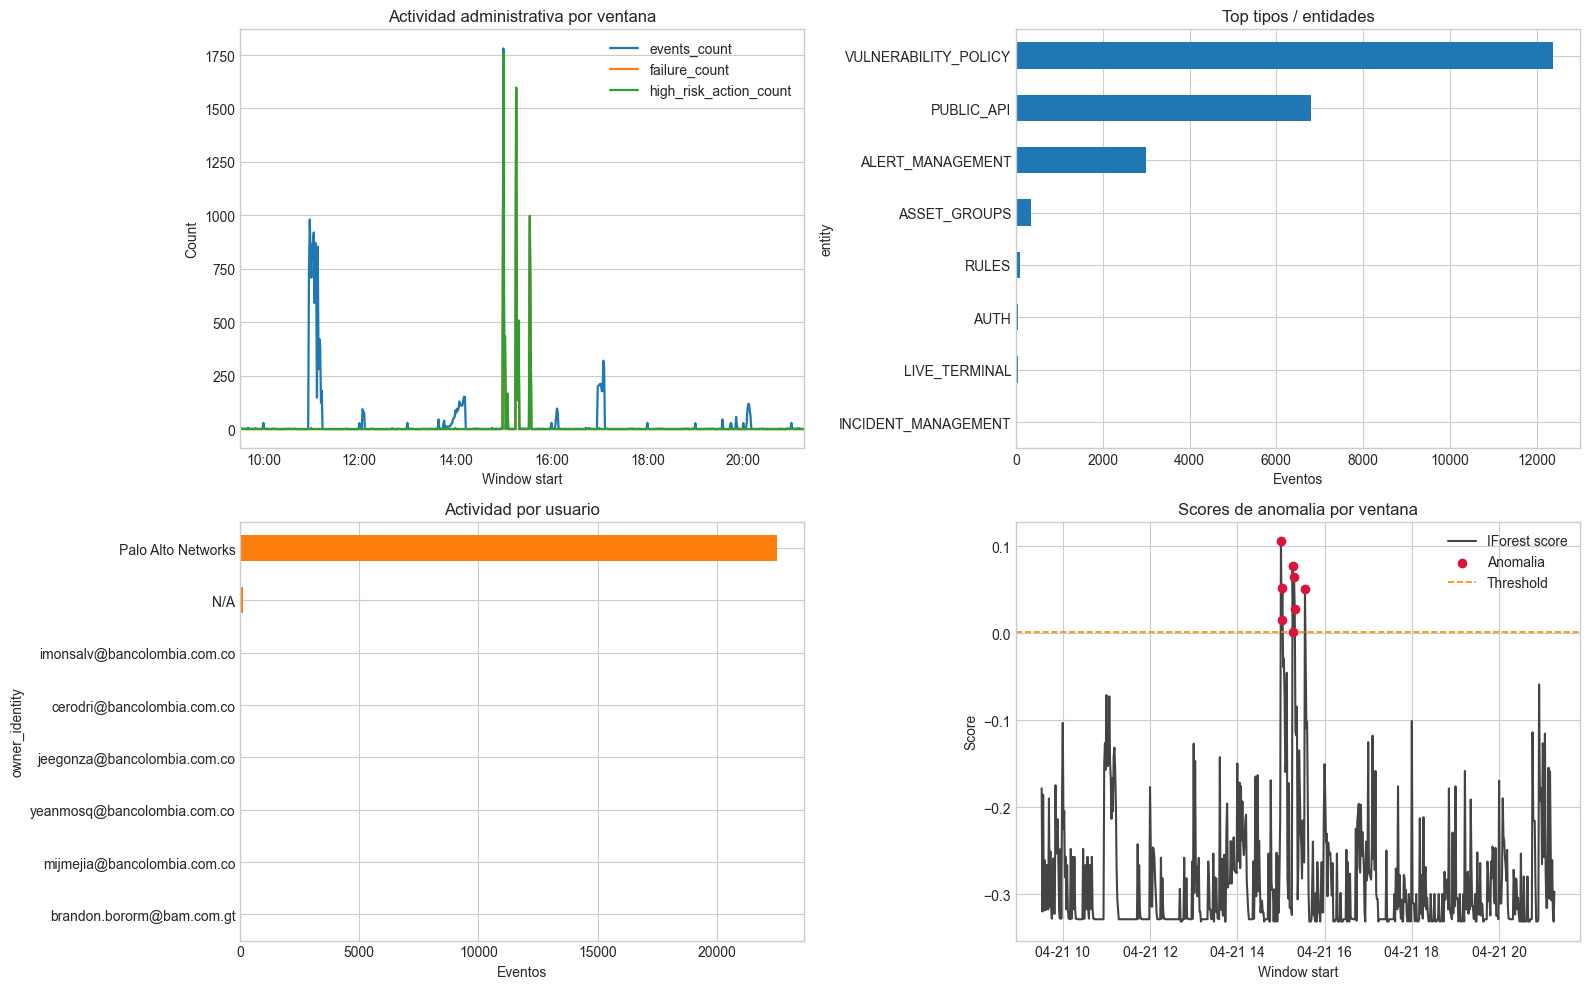

In [44]:
overview_path = paths.figures_dir / f'{extraction_id}_overview.png'

top_entities = normalized_df['entity'].value_counts().head(8)
top_users = normalized_df['owner_identity'].value_counts().head(8)
top_ips = normalized_df['source_ip'].dropna().astype(str).value_counts().head(8) if normalized_df['source_ip'].notna().any() else pd.Series(dtype=int)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

detected_df[['events_count', 'failure_count', 'high_risk_action_count']].plot(ax=axes[0, 0], linewidth=1.6)
axes[0, 0].set_title('Actividad administrativa por ventana')
axes[0, 0].set_xlabel('Window start')
axes[0, 0].set_ylabel('Count')

top_entities.sort_values().plot(kind='barh', ax=axes[0, 1], color='#1f77b4')
axes[0, 1].set_title('Top tipos / entidades')
axes[0, 1].set_xlabel('Eventos')

top_users.sort_values().plot(kind='barh', ax=axes[1, 0], color='#ff7f0e')
axes[1, 0].set_title('Actividad por usuario')
axes[1, 0].set_xlabel('Eventos')

axes[1, 1].plot(detected_df.index, detected_df['iforest_score'], color='#444444', linewidth=1.5, label='IForest score')
axes[1, 1].scatter(
    detected_df.index[detected_df['iforest_label'] == -1],
    detected_df.loc[detected_df['iforest_label'] == -1, 'iforest_score'],
    color='crimson',
    label='Anomalia',
    zorder=5,
)
axes[1, 1].axhline(iforest_threshold, color='darkorange', linestyle='--', linewidth=1.2, label='Threshold')
axes[1, 1].set_title('Scores de anomalia por ventana')
axes[1, 1].set_xlabel('Window start')
axes[1, 1].set_ylabel('Score')
axes[1, 1].legend(loc='best')

fig.tight_layout()
fig.savefig(overview_path, dpi=150, bbox_inches='tight')
display(overview_path)

if not top_ips.empty:
    display(top_ips.rename_axis('source_ip').reset_index(name='event_count'))

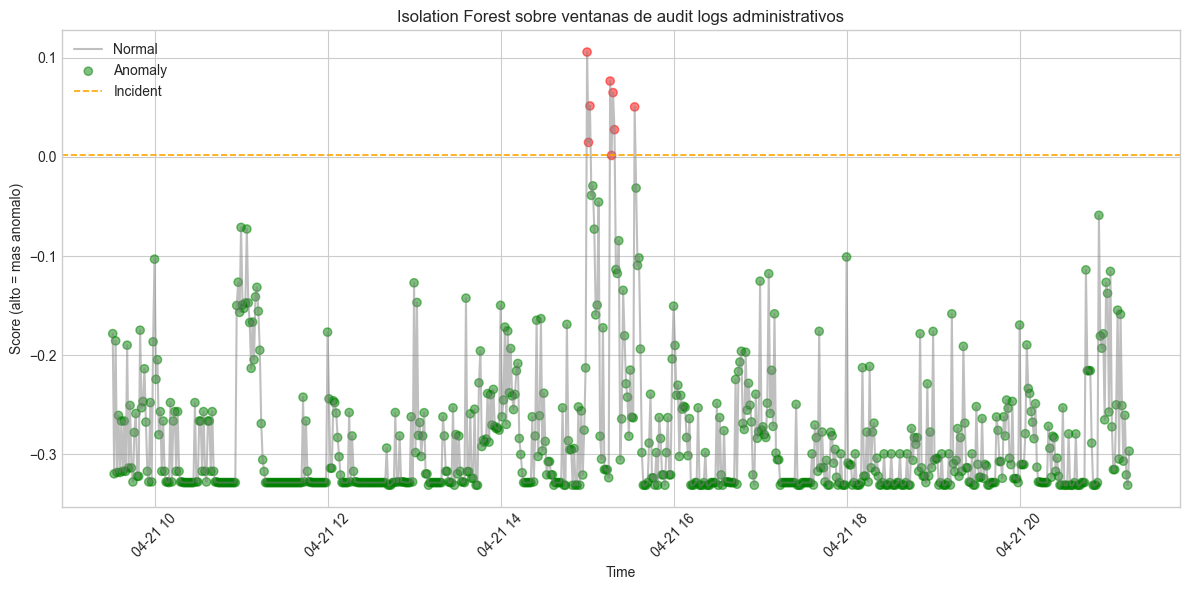

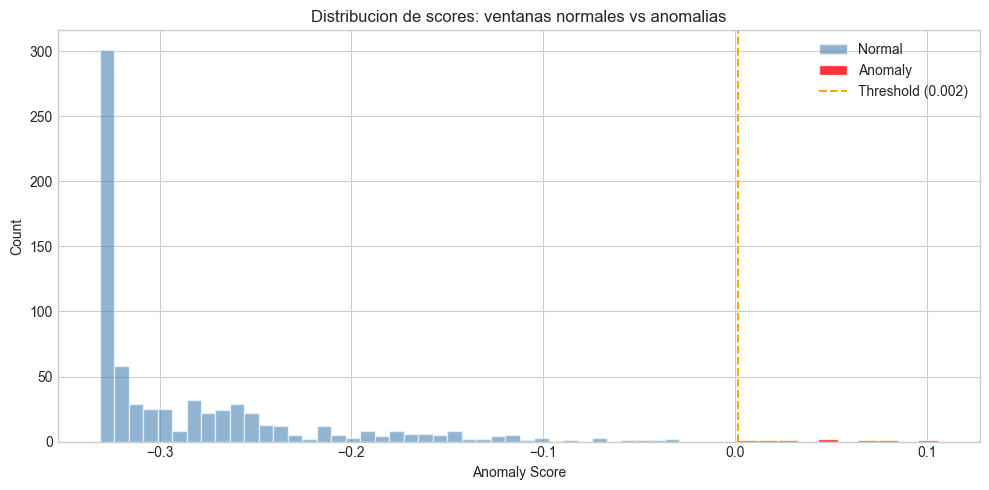

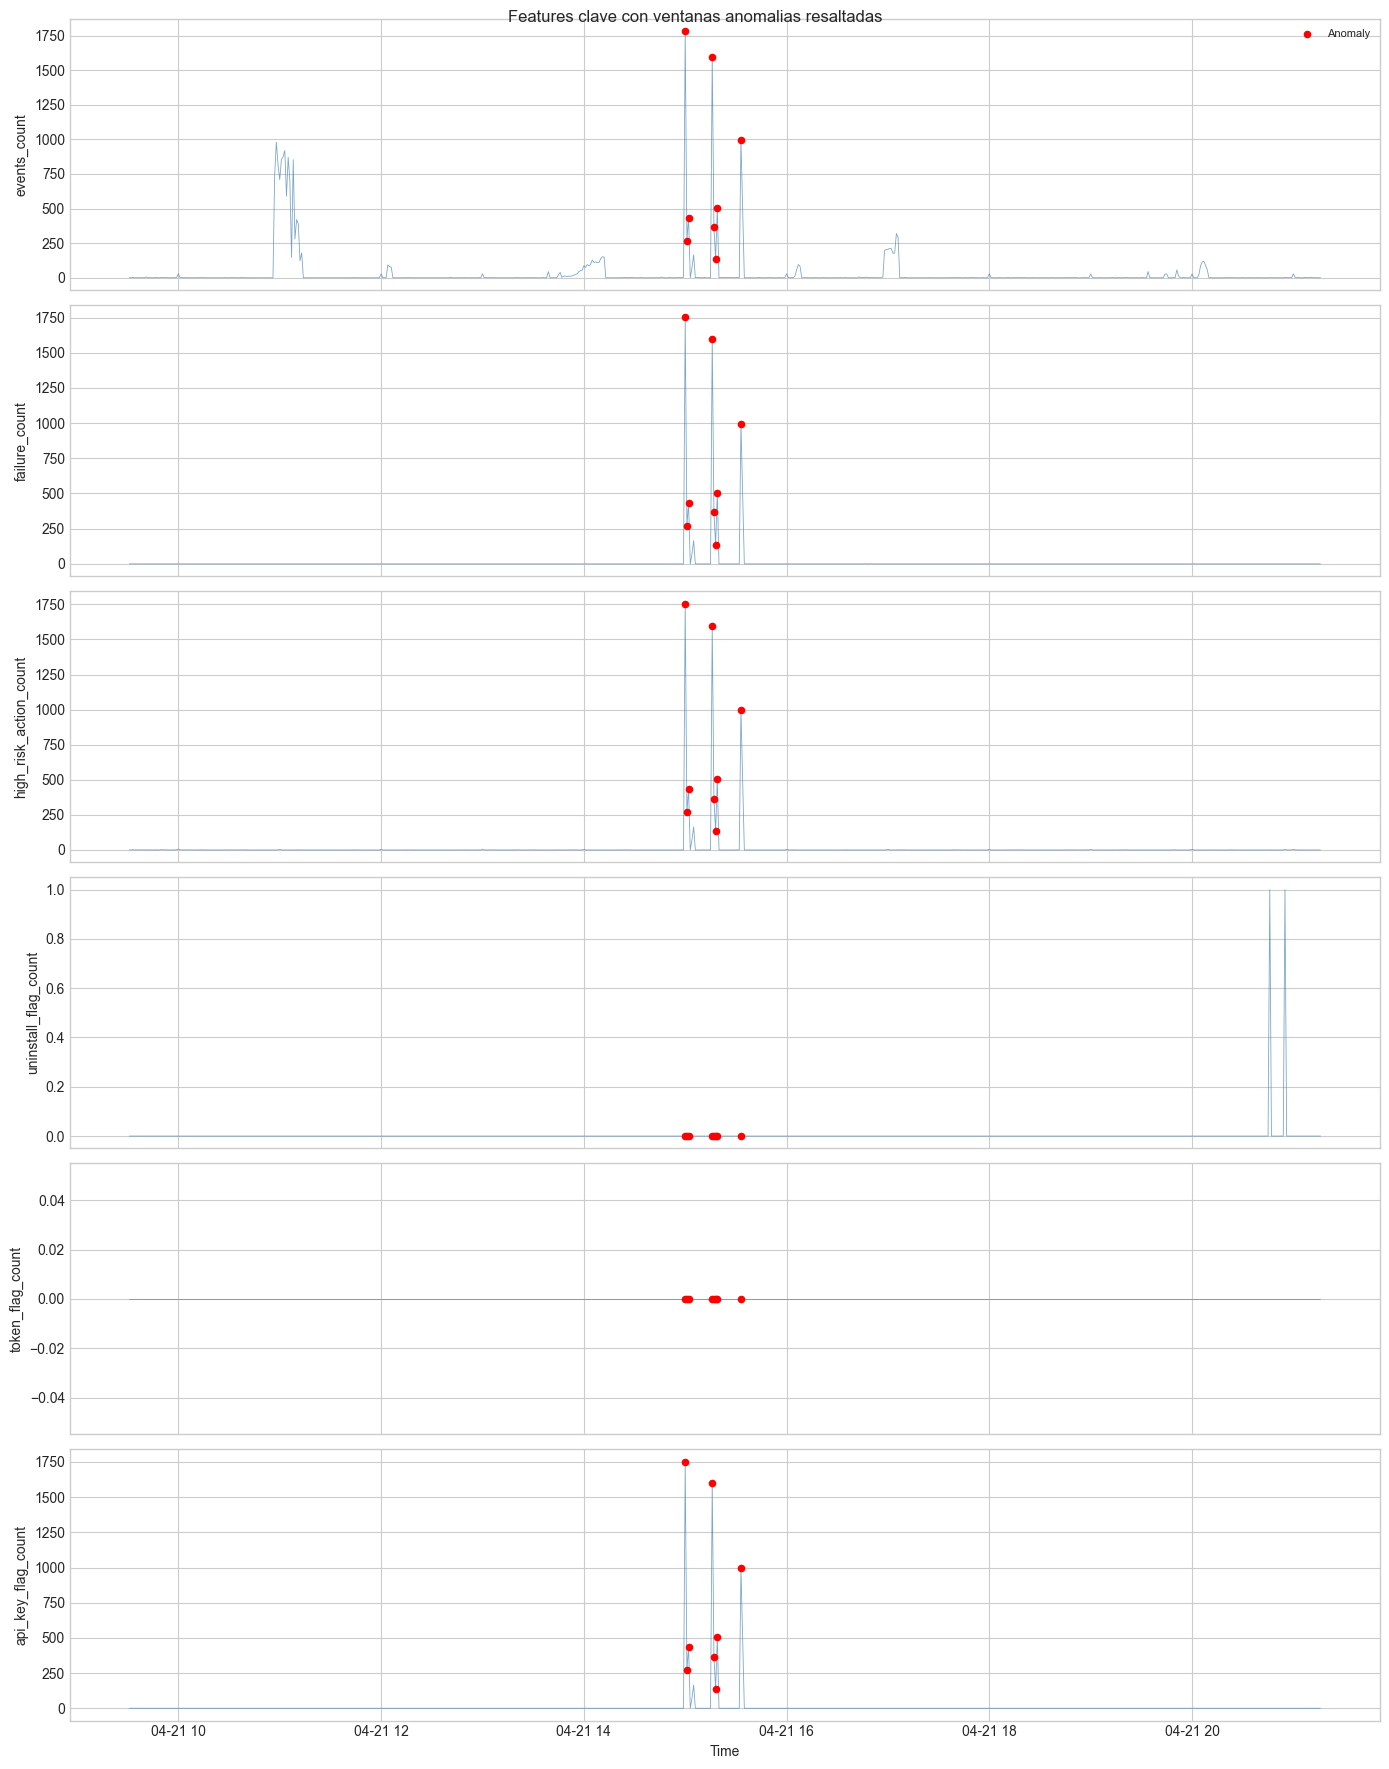

,event_time_local,owner_identity,entity,entity_subtype,result_normalized,source_ip,user_agent,iforest_score,description
0,2026-04-21 10:00:07-05:00,Palo Alto Networks,PUBLIC_API,Authentication failed,FAIL,NaN,NaN,0.105847,"Source IP: 3.23.24.49, API key ID: 40"
1,2026-04-21 10:00:08-05:00,Palo Alto Networks,ALERT_MANAGEMENT,Update Issue,SUCCESS,NaN,NaN,0.105847,Changed issue with id: 20978885 Observation Time to new value 1776783601484
2,2026-04-21 10:00:08-05:00,Palo Alto Networks,PUBLIC_API,Authentication failed,FAIL,NaN,NaN,0.105847,"Source IP: 3.23.24.49, API key ID: 40"
3,2026-04-21 10:00:08-05:00,Palo Alto Networks,ALERT_MANAGEMENT,Update Issue,SUCCESS,NaN,NaN,0.105847,Changed issue with id: 20978906 Observation Time to new value 1776783601484
4,2026-04-21 10:00:08-05:00,Palo Alto Networks,PUBLIC_API,Authentication failed,FAIL,NaN,NaN,0.105847,"Source IP: 3.23.24.49, API key ID: 40"
5,2026-04-21 10:00:08-05:00,Palo Alto Networks,PUBLIC_API,Authentication failed,FAIL,NaN,NaN,0.105847,"Source IP: 3.23.24.49, API key ID: 40"
6,2026-04-21 10:00:08-05:00,Palo Alto Networks,PUBLIC_API,Authentication failed,FAIL,NaN,NaN,0.105847,"Source IP: 3.23.24.49, API key ID: 40"
7,2026-04-21 10:00:08-05:00,Palo Alto Networks,PUBLIC_API,Authentication failed,FAIL,NaN,NaN,0.105847,"Source IP: 3.23.24.49, API key ID: 40"
8,2026-04-21 10:00:08-05:00,Palo Alto Networks,PUBLIC_API,Authentication failed,FAIL,NaN,NaN,0.105847,"Source IP: 3.23.24.49, API key ID: 40"
9,2026-04-21 10:00:08-05:00,Palo Alto Networks,PUBLIC_API,Authentication failed,FAIL,NaN,NaN,0.105847,"Source IP: 3.23.24.49, API key ID: 40"


In [45]:
viz_df = detected_df.copy()
viz = AnomalyVisualizer(viz_df, score_col='iforest_score', anomaly_col='iforest_label')
viz.plot_static(
    title='Isolation Forest sobre ventanas de audit logs administrativos',
    threshold=iforest_threshold,
    ylabel='Score (alto = mas anomalo)',
)
viz.plot_score_distribution(
    threshold=iforest_threshold,
    title='Distribucion de scores: ventanas normales vs anomalias',
)

feature_overlay_columns = [
    column for column in [
        'events_count', 'failure_count', 'high_risk_action_count',
        'uninstall_flag_count', 'token_flag_count', 'api_key_flag_count'
    ]
    if column in viz_df.columns
]
viz.plot_features(
    feature_columns=feature_overlay_columns,
    title='Features clave con ventanas anomalias resaltadas',
)

anomalous_event_df = link_events_to_anomalous_windows(
    normalized_df,
    viz_df,
    time_window=TIME_WINDOW,
    label_column='iforest_label',
    score_column='iforest_score',
)
event_view_columns = [
    'event_time_local', 'owner_identity', 'entity', 'entity_subtype', 'result_normalized',
    'source_ip', 'user_agent', 'iforest_score', 'description'
]
event_view_columns = [column for column in event_view_columns if column in anomalous_event_df.columns]
anomalous_event_df[event_view_columns].head(25)

## 12. Hallazgos

Esta seccion no pretende cerrar el caso de uso. Busca dejar una lectura tecnica clara de lo que ya muestra valor y de lo que todavia depende de mas historico.

In [46]:
candidate_windows = detected_df.sort_values('iforest_score', ascending=False).head(5)
candidate_window_columns = [
    column for column in [
        'iforest_score', 'events_count', 'failure_count', 'high_risk_action_count',
        'uninstall_flag_count', 'token_flag_count', 'api_key_flag_count',
        'high_risk_sequence_count', 'rare_action_count', 'outside_business_hours_count'
    ]
    if column in candidate_windows.columns
]

print('Campos mas prometedores observados en esta corrida:')
display(field_table[field_table['relevancia_analitica'] == 'Alta'].head(12))

print('Features con mas outliers IQR segun Explorer:')
display(signal_summary[['feature', 'variance', 'iqr_anomaly_pct']].head(12))

print('Ventanas candidatas a anomalia segun Isolation Forest:')
display(candidate_windows[candidate_window_columns])

if not anomalous_event_df.empty:
    print('Eventos contenidos en ventanas anomalias:')
    display(anomalous_event_df[event_view_columns].head(25))

Campos mas prometedores observados en esta corrida:


,campo,descripcion_inferida,relevancia_analitica,uso_potencial,fortaleza_esperada,limitaciones
0,AUDIT_ASSET_JSON,Detalle estructurado del activo o assets impactados.,Alta,"Correlación fina con endpoints, tags o grupos afectados.",Alta si el JSON es consistente.,Puede venir como string serializado y requerir flattening.
1,AUDIT_ASSET_NAMES,Activos o nombres de activos asociados a la acción.,Alta,"Blast radius, uninstall masivo y cambios con impacto de cobertura.",Alta cuando viene poblado.,Formato y delimitación pueden variar; requiere parsing adicional.
2,AUDIT_DESCRIPTION,Descripción textual del cambio o acción ejecutada.,Alta,"Banderas semánticas para uninstall, token, API key, config y Action Center.",Alta para enriquecer contexto de anomalías.,"Puede ser largo, ruidoso o cambiar entre releases."
3,AUDIT_ENTITY,Familia o tipo principal de evento administrativo.,Alta,"Volumetría por dominio, rareza de acciones y detección de picos por categoría.",Alta.,Granularidad media; por sí sola puede ocultar subtipos críticos.
4,AUDIT_ENTITY_SUBTYPE,Subtipo más específico del evento administrativo.,Alta,"Rare actions, cambios críticos concretos y secuencias operativas.",Alta cuando la cardinalidad es manejable.,Puede ser muy disperso y requerir normalización semántica.
5,AUDIT_INSERT_TIME,Marca temporal del evento administrativo.,Alta,"Series temporales, estacionalidad, bursts y secuencias.",Alta.,Hay que confirmar zona horaria y semántica exacta del timestamp.
6,AUDIT_OWNER_EMAIL,Correo del actor administrativo.,Alta,"Identidad primaria para baselines, rareza y first-seen.",Alta si el tenant usa identidades personales.,Se debilita con service accounts o automatizaciones impersonales.
7,AUDIT_OWNER_NAME,Nombre visible del actor administrativo.,Alta,Perfiles de comportamiento por administrador y secuencias por usuario.,Media a alta según consistencia operativa.,"Puede variar por alias, cambios de display name o cuentas compartidas."
8,AUDIT_RESULT,Resultado de la acción administrativa.,Alta,"Detección de bursts de fallo, pruebas erróneas y cambios rechazados.",Alta cuando existe taxonomía consistente de estados.,Las etiquetas exactas pueden variar entre tipos y versiones.
9,AUDIT_SOURCE_IP,IP de origen observada para la acción administrativa.,Alta,"First-seen por usuario, rareza de origen y posibles automatizaciones no habituales.",Alta si la IP está presente y estable.,"Puede ocultarse detrás de proxys, NAT o planos de control internos."


Features con mas outliers IQR segun Explorer:


,feature,variance,iqr_anomaly_pct
55,events_count_delta_from_rolling_mean,8.738312e+03,23.94
41,events_count_rolling_mean,1.385696e+04,22.10
61,unique_ips_delta_from_rolling_mean,1.695721e-01,21.81
42,events_count_rolling_std,1.023246e+04,21.39
63,high_risk_action_count_delta_from_rolling_mean,6.847050e+03,19.55
62,unique_ips_zscore_like,4.425085e-01,19.26
64,high_risk_action_count_zscore_like,2.950352e-01,18.98
40,burstiness_index,1.128526e+07,18.70
34,user_count__palo_alto_networks,2.200439e+04,18.70
9,max_time_between_events_seconds,5.602727e+01,18.70


Ventanas candidatas a anomalia segun Isolation Forest:


,iforest_score,events_count,failure_count,high_risk_action_count,uninstall_flag_count,token_flag_count,api_key_flag_count,high_risk_sequence_count,rare_action_count,outside_business_hours_count
window_start,,,,,,,,,,
2026-04-21 15:00:00+00:00,0.105847,1781,1751,1756,0,0,1751,1753,0,0
2026-04-21 15:16:00+00:00,0.076589,1597,1597,1597,0,0,1597,1597,0,0
2026-04-21 15:18:00+00:00,0.064924,137,135,135,0,0,135,135,0,0
2026-04-21 15:02:00+00:00,0.051488,435,433,433,0,0,433,433,2,0
2026-04-21 15:33:00+00:00,0.050515,997,997,997,0,0,997,996,0,0


Eventos contenidos en ventanas anomalias:


,event_time_local,owner_identity,entity,entity_subtype,result_normalized,source_ip,user_agent,iforest_score,description
0,2026-04-21 10:00:07-05:00,Palo Alto Networks,PUBLIC_API,Authentication failed,FAIL,NaN,NaN,0.105847,"Source IP: 3.23.24.49, API key ID: 40"
1,2026-04-21 10:00:08-05:00,Palo Alto Networks,ALERT_MANAGEMENT,Update Issue,SUCCESS,NaN,NaN,0.105847,Changed issue with id: 20978885 Observation Time to new value 1776783601484
2,2026-04-21 10:00:08-05:00,Palo Alto Networks,PUBLIC_API,Authentication failed,FAIL,NaN,NaN,0.105847,"Source IP: 3.23.24.49, API key ID: 40"
3,2026-04-21 10:00:08-05:00,Palo Alto Networks,ALERT_MANAGEMENT,Update Issue,SUCCESS,NaN,NaN,0.105847,Changed issue with id: 20978906 Observation Time to new value 1776783601484
4,2026-04-21 10:00:08-05:00,Palo Alto Networks,PUBLIC_API,Authentication failed,FAIL,NaN,NaN,0.105847,"Source IP: 3.23.24.49, API key ID: 40"
5,2026-04-21 10:00:08-05:00,Palo Alto Networks,PUBLIC_API,Authentication failed,FAIL,NaN,NaN,0.105847,"Source IP: 3.23.24.49, API key ID: 40"
6,2026-04-21 10:00:08-05:00,Palo Alto Networks,PUBLIC_API,Authentication failed,FAIL,NaN,NaN,0.105847,"Source IP: 3.23.24.49, API key ID: 40"
7,2026-04-21 10:00:08-05:00,Palo Alto Networks,PUBLIC_API,Authentication failed,FAIL,NaN,NaN,0.105847,"Source IP: 3.23.24.49, API key ID: 40"
8,2026-04-21 10:00:08-05:00,Palo Alto Networks,PUBLIC_API,Authentication failed,FAIL,NaN,NaN,0.105847,"Source IP: 3.23.24.49, API key ID: 40"
9,2026-04-21 10:00:08-05:00,Palo Alto Networks,PUBLIC_API,Authentication failed,FAIL,NaN,NaN,0.105847,"Source IP: 3.23.24.49, API key ID: 40"


## Tablas Finales Obligatorias

Las dos tablas siguientes quedan listas para exportarse y reutilizarse en la siguiente iteracion.

In [47]:
taxonomy_table = build_anomaly_taxonomy_table(normalized_df, feature_df)
dataframe_to_csv(taxonomy_table, taxonomy_table_path)

print('Tabla 1: interpretacion de campos')
display(field_table)

print('Tabla 2: taxonomia de anomalias')
display(taxonomy_table)

Tabla 1: interpretacion de campos


,campo,descripcion_inferida,relevancia_analitica,uso_potencial,fortaleza_esperada,limitaciones
0,AUDIT_ASSET_JSON,Detalle estructurado del activo o assets impactados.,Alta,"Correlación fina con endpoints, tags o grupos afectados.",Alta si el JSON es consistente.,Puede venir como string serializado y requerir flattening.
1,AUDIT_ASSET_NAMES,Activos o nombres de activos asociados a la acción.,Alta,"Blast radius, uninstall masivo y cambios con impacto de cobertura.",Alta cuando viene poblado.,Formato y delimitación pueden variar; requiere parsing adicional.
2,AUDIT_DESCRIPTION,Descripción textual del cambio o acción ejecutada.,Alta,"Banderas semánticas para uninstall, token, API key, config y Action Center.",Alta para enriquecer contexto de anomalías.,"Puede ser largo, ruidoso o cambiar entre releases."
3,AUDIT_ENTITY,Familia o tipo principal de evento administrativo.,Alta,"Volumetría por dominio, rareza de acciones y detección de picos por categoría.",Alta.,Granularidad media; por sí sola puede ocultar subtipos críticos.
4,AUDIT_ENTITY_SUBTYPE,Subtipo más específico del evento administrativo.,Alta,"Rare actions, cambios críticos concretos y secuencias operativas.",Alta cuando la cardinalidad es manejable.,Puede ser muy disperso y requerir normalización semántica.
5,AUDIT_INSERT_TIME,Marca temporal del evento administrativo.,Alta,"Series temporales, estacionalidad, bursts y secuencias.",Alta.,Hay que confirmar zona horaria y semántica exacta del timestamp.
6,AUDIT_OWNER_EMAIL,Correo del actor administrativo.,Alta,"Identidad primaria para baselines, rareza y first-seen.",Alta si el tenant usa identidades personales.,Se debilita con service accounts o automatizaciones impersonales.
7,AUDIT_OWNER_NAME,Nombre visible del actor administrativo.,Alta,Perfiles de comportamiento por administrador y secuencias por usuario.,Media a alta según consistencia operativa.,"Puede variar por alias, cambios de display name o cuentas compartidas."
8,AUDIT_RESULT,Resultado de la acción administrativa.,Alta,"Detección de bursts de fallo, pruebas erróneas y cambios rechazados.",Alta cuando existe taxonomía consistente de estados.,Las etiquetas exactas pueden variar entre tipos y versiones.
9,AUDIT_SOURCE_IP,IP de origen observada para la acción administrativa.,Alta,"First-seen por usuario, rareza de origen y posibles automatizaciones no habituales.",Alta si la IP está presente y estable.,"Puede ocultarse detrás de proxys, NAT o planos de control internos."


Tabla 2: taxonomia de anomalias


,tipo_de_anomalia,detectabilidad_con_dataset_actual,features_candidatas,dependencia_de_mayor_historico,prioridad_siguiente_iteracion
0,Picos de volumen administrativo,Media,"events_count, entity_count__*, unique_admins, events_count_zscore_like",Deseable para separar bursts legítimos de mantenimiento programado.,Alta
1,Actividad inusual por usuario,Media en validación rápida; mejora de forma importante con más histórico,"user_count__*, unique_admins, rare_action_count, high_risk_sequence_count",Alta para construir perfil de habitualidad por administrador.,Alta
2,Acciones desde IP o user-agent no habitual,Media en validación rápida; mejora de forma importante con más histórico,"first_seen_ip_count, first_seen_user_agent_count, unique_ips, unique_user_agents",Alta; el valor crece mucho con memoria histórica por usuario.,Media-Alta
3,Aumento de acciones fallidas,Media,"failure_count, failure_ratio, failed_admins_nunique, authentication_flag_count",Media; con pocas horas sigue siendo útil para bursts evidentes.,Alta
4,Generación anómala de tokens o API keys,Media en validación rápida; mejora de forma importante con más histórico,"token_flag_count, api_key_flag_count, rare_action_count, user_count__*",Alta para distinguir operación rara legítima de abuso.,Alta
5,Desinstalación masiva de agentes o pérdida de cobertura,Media,"uninstall_flag_count, unique_hostnames, assets_nunique, high_risk_action_count",Media; un burst fuerte puede verse incluso con ventana corta.,Muy alta
6,Secuencias administrativas de alto riesgo,Media en validación rápida; mejora de forma importante con más histórico,"high_risk_sequence_count, sequence_signature, previous_is_failure -> success",Media-Alta; más sesiones observadas mejoran el baseline.,Alta
7,Cambios con impacto potencial de disponibilidad,Media,"config_flag_count, action_center_flag_count, permissions_flag_count, high_risk_action_ratio",Alta para separar cambios planeados de desviaciones operativas.,Muy alta
